### Построение первой модели нейронной сети

Ф-ия активация => Ф-ия потерь => Градиентный спуск => Метрика

In [220]:
import torch
import torch.nn as nn

### Последовательная модель

In [221]:
model = nn.Sequential(
    nn.Linear(784, 128),
    nn. ReLU(),
    nn.Linear(128, 10)
)

In [222]:
model

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

16 - размер батча. На выходе модель возвращает тензор размером 16x10

In [223]:
input = torch.rand([16, 784], dtype=torch.float32)
out = model(input)
out.shape

torch.Size([16, 10])

Методы модели:

In [224]:
#model.state_dict() # Все параметры модели по слоям
#model.state_dict()['0.weight']
#model.state_dict()['0.bias']

# for parameter in model.parameters(): # Все обучаемые параметры модели
#     print(parameter)
#     print(parameter.shape, end='\n\n')

# Следующие два метода используются при тренировке и валидации, потому что
# если модель содержит Dropout и Batchnorm, то работы будет отличаться при тренировке и валидации
# model.train()
# model.eval()

Способ создания модели

In [225]:
model = nn.Sequential()
model.add_module('layer_1', nn.Linear(784,128))
model.add_module('relu', nn.ReLU())
model.add_module('layer_2', nn.Linear(128,10))

In [226]:
print(model,
model.relu,
model.layer_1, sep='\n')

Sequential(
  (layer_1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (layer_2): Linear(in_features=128, out_features=10, bias=True)
)
ReLU()
Linear(in_features=784, out_features=128, bias=True)


In [227]:
input = torch.rand([16,784], dtype=torch.float32)
out = model(input)
out.shape

torch.Size([16, 10])

In [228]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.0089,  0.0282, -0.0160,  ...,  0.0027,  0.0186,  0.0244],
                      [ 0.0238,  0.0034, -0.0051,  ..., -0.0283, -0.0194, -0.0178],
                      [-0.0150, -0.0144, -0.0306,  ..., -0.0318,  0.0313,  0.0272],
                      ...,
                      [-0.0171,  0.0159,  0.0346,  ..., -0.0193, -0.0345, -0.0295],
                      [ 0.0148,  0.0138,  0.0116,  ...,  0.0053, -0.0073, -0.0029],
                      [-0.0023,  0.0046, -0.0216,  ..., -0.0045,  0.0108, -0.0084]])),
             ('layer_1.bias',
              tensor([ 0.0346, -0.0058,  0.0114,  0.0304, -0.0293,  0.0146, -0.0163, -0.0068,
                       0.0334, -0.0079, -0.0035, -0.0280,  0.0308,  0.0133, -0.0026, -0.0109,
                       0.0348,  0.0043,  0.0044, -0.0166,  0.0098, -0.0250,  0.0215, -0.0122,
                      -0.0252,  0.0306,  0.0044, -0.0350,  0.0318,  0.0157, -0.0099, -0.0313,
                       0.010

### Создание класса для модели

In [229]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model = MyModel(784, 10)

In [230]:
input = torch.rand([16,784], dtype=torch.float32)
out = model(input)
out.shape

torch.Size([16, 10])

Модель с двумя взодами и выходами

In [231]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x, y):
        x = self.layer_1(x)
        x = self.act(x + y)
        out = self.layer_2(x)
        return out, x

model = MyModel(784,10)

In [232]:
x = torch.rand([16,784], dtype=torch.float32)
y = torch.rand([16,128], dtype=torch.float32)
out = model(x,y)

Выход содержит 2 элемента, как нам и надо. Размеры выходных тензоров такие, как и планировались

In [233]:
print(len(out), out[0].shape, out[1].shape, sep='\n')

2
torch.Size([16, 10])
torch.Size([16, 128])


Создание модели с помощью ModuleList и ModeluDict

* ModuleList: обычный список, доступ можно получить по индексу
* ModuleDict: словарь, в котором доступ получается по ключу

In [234]:
class MyModel(nn.Module):
    def __init__(self, input, output, hidden_size=2048):
        super().__init__()

        # self.actications = nn.ModuleDict({
        #     'lrelu': nn.LeakyReLU(),
        #     'relu': nn.ReLU()
        # })

        self.layers = nn.ModuleList()
        for i in range(10):
            self.layers.add_module(f'layer_{i}', nn.Linear(input, hidden_size))
            self.layers.add_module(f'act_{i}', nn.ReLU())
            input = hidden_size
            hidden_size = int(hidden_size / 2)
        self.layers.add_module(f'output_{i}', nn.Linear(input, output))

    def forward(self, x):
        output = []
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i!=0 and i%2==0 and i%4!=0:
                output.append(x)
        output.append(x)
        return output

In [235]:
model = MyModel(784, 2)
model

MyModel(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=64, bias=True)
    (11): ReLU()
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=16, bias=True)
    (15): ReLU()
    (16): Linear(in_features=16, out_features=8, bias=True)
    (17): ReLU()
    (18): Linear(in_features=8, out_features=4, bias=True)
    (19): ReLU()
    (20): Linear(in_features=4, out_features=2, bias=True)
  )
)

In [236]:
input = torch.rand([16, 784], dtype=torch.float32)
out = model(input)

In [237]:
len(out)
for i in range(6):
    print(f'out_shape{i+1} = {out[i].shape}')

out_shape1 = torch.Size([16, 1024])
out_shape2 = torch.Size([16, 256])
out_shape3 = torch.Size([16, 64])
out_shape4 = torch.Size([16, 16])
out_shape5 = torch.Size([16, 4])
out_shape6 = torch.Size([16, 2])


### Создание модели для классификации MNIST

In [238]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model_classification = MyModel(784,10)

Определяем ф-ию потерь

In [239]:
loss = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model_classification.parameters(), lr=0.001)

In [240]:
input = torch.rand([16,784], dtype=torch.float32)
out = model_classification(input)
out.shape

torch.Size([16, 10])

### Модель для задачи регрессии

In [241]:
model_regression = MyModel(64*64, 2) # на вход подается фото 64х64, на выходе получаем координаты

loss = nn.MSELoss()
opt = torch.optim.Adam(model_regression.parameters(), lr=0.001)

In [242]:
input = torch.rand([16, 64*64], dtype=torch.float32)
out = model_regression(input)
out.shape

torch.Size([16, 2])

### Создание цикла обучения
Данные есть, модели есть, остальось их обучить

In [243]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import os, json, matplotlib.pyplot as plt, numpy as np
from tqdm import tqdm
from PIL import Image

In [244]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

### Создание Dataset

In [245]:
class MNISTDataset(Dataset):
    def __init__(self,path,transform=None):
        self.path = path
        self.transform = transform

        self.len_dataset=0
        self.data_list=[]

        for path_dir, dir_list, file_list in os.walk(path): #путь папки, вложенные папки и файлы
            if path_dir == path:
                self.classes = dir_list
                self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
                continue

            cls = os.path.basename(path_dir) # Имя последней папки/файла из пути

            for name_file in file_list:
                file_path = os.path.join(path_dir, name_file) #объединяет путь к папке и имя файла в один путь к файлу
                self.data_list.append((file_path, self.class_to_idx[cls])) #добавляет пару «путь к файлу и числовой индекс его класса»

            self.len_dataset += len(file_list)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        file_path, target = self.data_list[index]
        sample = np.array(Image.open(file_path))

        if self.transform is not None:
            sample = self.transform(sample)

        return sample, target


In [246]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,),std=(0.5,))
    ]
)

In [247]:
train = MNISTDataset(r'/content/C:\Users\arato\Desktop\It_programms\PyTorch/mnist_images/training', transform=transform)
test = MNISTDataset(r'/content/C:\Users\arato\Desktop\It_programms\PyTorch/mnist_images/testing', transform=transform)

In [248]:
len(train)

60000

In [249]:
train, val = random_split(train, [0.7,0.3])

In [250]:
train_loader = DataLoader(train, 64, True)
val_loader = DataLoader(val, 64, False)
test_loader = DataLoader(test, 64, False)

### Создание модели

In [251]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model = MyModel(784,10).to(device) # cpu

In [252]:
input = torch.rand([16,784], dtype=torch.float32).to(device)
out = model(input)

out.shape

torch.Size([16, 10])

In [253]:
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

### Тренировка модели

In [254]:
# Цикл обучения:
#     Тренировка модели
#         Данные
#         Прямой проход + ошибка
#         Обратный проход
#         Оптимизация (градиент)
#     Расчет метрики
#     Сохранение значений ф-ии потерь и метрики

#     Валидация
#         Данные
#         Прямой проход + ошибка
#     Расчет метрики
#     Сохранение значений ф-ии потерь и метрики

In [ ]:
EPOCHS = 10
train_loss = []
val_loss = []
train_acc = []
val_acc = []

for epoch in range(EPOCHS):

    model.train()
    running_train_loss = []
    true_answer = 0
    train_loop = tqdm(train_loader, leave=False)
    for x, targets in train_loop:
        # (batch_size, 1, 28*28) -> (batch_size, 784)
        x = x.reshape(-1,28*28).to(device)
        # (batch_size, int) -> (batch_size, 10), dtype=float32
        targets = targets.reshape(-1).to(torch.int32)
        targets = torch.eye(10)[targets].to(device)

        # Прямой проход + ошибка
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()

        # Шаг оптимизации
        opt.step()

        # Добавление значения ф-ии потерь в список
        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss)/len(running_train_loss)
        true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()
        # Доп информация
        train_loop.set_description(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}')

    # Расчет значения метрики
    running_train_acc = true_answer/len(train)
    # Сохрание значений ф-им потерь и метрики
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)


    # Проверка модели(валидация)
    model.eval()
    with torch.no_grad(): # Запрещаем вычисление градиентов в цикле
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            x = x.reshape(-1, 28*28).to(device)

            targets = targets.reshape(-1).to(torch.int32)
            targets = torch.eye(10)[targets].to(device)
            # Прямой проход + ошибка
            pred = model(x)
            loss = loss_model(pred, targets)

            # Добавление значения ф-ии потерь в список
            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss)/len(running_val_loss)

            true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()
        # Расчет значения метрики
        running_val_acc = true_answer / len(val)

        # Сохрание значений ф-им потерь и метрики
        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

        print(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}, train_acc: {running_train_acc:.4f}, val_loss: {mean_val_loss:.4f}, val_acc: {running_val_acc:.4f}')

Epoch: [1/10], train_loss: 0.4441, train_acc: 0.8692, val_loss: 0.3030, val_acc: 0.9117


Epoch: [2/10], train_loss: 0.2439, train_acc: 0.9275, val_loss: 0.2010, val_acc: 0.9399


In [ ]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend()

In [ ]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend()

### Задача рергессии

In [ ]:
class DataReg(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.list_name_file = os.listdir(path)
        if 'coords.json' in self.list_name_file:
            self.list_name_file.remove('coords.json')

        self. len_dataset = len(self.list_name_file)

        with open(os.path.join(self.path, 'coords.json'), 'r') as f:
            self.dict_coords = json.load((f))

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        name_file = self.list_name_file[index]
        path_img = os.path.join(self.path, name_file)

        img = np.array(Image.open(path_img))
        coord = np.array(self.dict_coords[name_file])

        if self.transform is not None:
            img = self.transform(img)

        return img, coord

In [ ]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,),std=(0.5,))
    ]
)

In [ ]:
dataset = DataReg(r'/content/dataset', transform=transform)

In [ ]:
img, coord = dataset[98765]
print(f'Координаты: {coord}')
plt.imshow(img.numpy()[0], cmap='gray')

In [ ]:
train, val, test = random_split(dataset, [0.7,0.1,0.2])

In [ ]:
train_loader = DataLoader(train, 16, True)
val_loader = DataLoader(val, 16, False)
test_loader = DataLoader(test, 16, False)

In [ ]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model = MyModel(64*64, 2).to(device)

In [ ]:
input = torch.rand([16,64*64], dtype=torch.float32).to(device)
out = model(input)
out.shape

In [ ]:
loss_model = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(),lr=0.001)

In [ ]:
train_loss = []
val_loss = []
train_acc = []
val_acc = []

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = []
    true_answer = 0
    train_loop = tqdm(train_loader, leave=False)

    for x, targets in train_loop:
        x = x.reshape(-1, 64 * 64).to(device)
        targets = targets.to(device).float()  

        # Прямой проход + ошибка
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()

        # Шаг оптимизации
        opt.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)
        true_answer += (pred.round() == targets).all(dim=1).sum().item()  
        train_loop.set_description(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}')

    running_train_acc = true_answer / len(train)
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:  
            x = x.reshape(-1, 64 * 64).to(device)
            targets = targets.to(device).float() 

            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            true_answer += (pred.round() == targets).all(dim=1).sum().item()

        mean_val_loss = sum(running_val_loss) / len(running_val_loss)
        running_val_acc = true_answer / len(val)

        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

    print(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}, train_acc: {running_train_acc:.4f}, val_loss: {mean_val_loss:.4f}, val_acc: {running_val_acc:.4f}')

Epoch: [1/10], train_loss: 2.2976, train_acc: 0.6473, val_loss: 0.1005, val_acc: 0.7778


Epoch: [2/10], train_loss: 0.1219, train_acc: 0.7222, val_loss: 0.1593, val_acc: 0.6060


Epoch: [3/10], train_loss: 0.1105, train_acc: 0.7553, val_loss: 0.1191, val_acc: 0.7227


Epoch: [4/10], train_loss: 0.0992, train_acc: 0.7940, val_loss: 0.0892, val_acc: 0.8227


Epoch: [5/10], train_loss: 0.0904, train_acc: 0.8214, val_loss: 0.1146, val_acc: 0.7402


Epoch: [6/10], train_loss: 0.0826, train_acc: 0.8452, val_loss: 0.0920, val_acc: 0.8079


Epoch: [7/10], train_loss: 0.0760, train_acc: 0.8674, val_loss: 0.0570, val_acc: 0.9298


Epoch: [8/10], train_loss: 0.0730, train_acc: 0.8767, val_loss: 0.0690, val_acc: 0.8923


Epoch: [9/10], train_loss: 0.0690, train_acc: 0.8880, val_loss: 0.0604, val_acc: 0.9176


Epoch: [10/10], train_loss: 0.0668, train_acc: 0.8958, val_loss: 0.0485, val_acc: 0.9493


In [210]:
pred = torch.tensor([[25.1,44.8],[52.3,27.8],[12.7,37.4],[29.3,27.2]], dtype=torch.float32, requires_grad=True).to(device)
target = torch.tensor([[25,45],[53,28],[13,38],[30,28]], dtype=torch.float32).to(device)
print(pred, end='\n\n')
print(target)

tensor([[25.1000, 44.8000],
        [52.3000, 27.8000],
        [12.7000, 37.4000],
        [29.3000, 27.2000]], requires_grad=True)

tensor([[25., 45.],
        [53., 28.],
        [13., 38.],
        [30., 28.]])


In [211]:
torch.round(pred)

tensor([[25., 45.],
        [52., 28.],
        [13., 37.],
        [29., 27.]], grad_fn=<RoundBackward0>)

In [212]:
torch.round(pred) == target

tensor([[ True,  True],
        [False,  True],
        [ True, False],
        [False, False]])

In [213]:
print((torch.round(pred) == target).all(dim=1))
print((torch.round(pred) == target).all(dim=1).sum())
print((torch.round(pred) == target).all(dim=1).sum().item())

tensor([ True, False, False, False])
tensor(1)
1


/tmp/ipykernel_446/1799940628.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


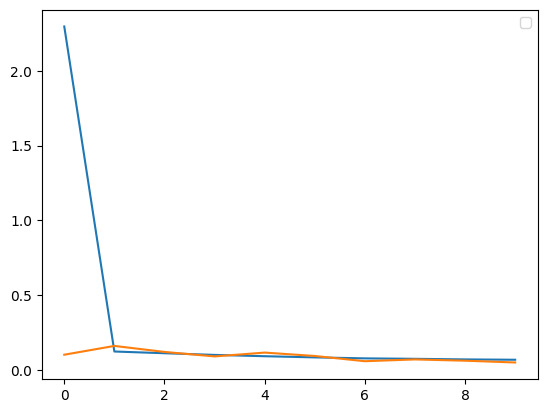

In [214]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend()

/tmp/ipykernel_446/1309107087.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


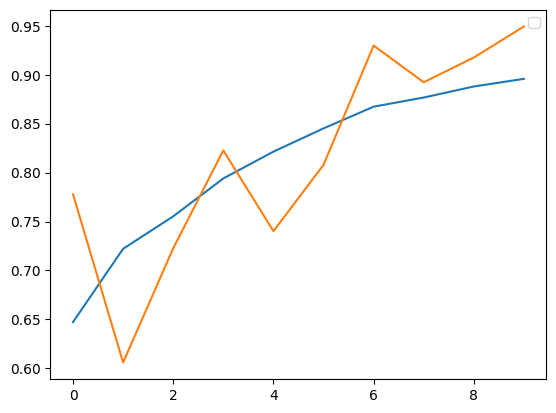

In [215]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend()

### Проверка модели